In [1]:
import nilearn
import numpy as np
import nibabel as nib
import pandas as pd
from sklearn.cluster import KMeans
from nilearn import plotting as nplt
from sklearn.metrics import pairwise_distances
from pathlib import Path
from sklearn.metrics import davies_bouldin_score, silhouette_score
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings


warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
random_state = 42

# Introduction


# Settings

In [2]:
# Folders
DATASET_FOLDER = Path("/home/guoqiu/guoqiu/Database/VMPFC/GMV")
FILENAME_PATTERN = '*_T1w_struc_GM_to_template_GM_mod.nii.gz'

DATA_FOLDER = Path('../data')
RESULT_FOLDER = Path('../results')

In [3]:
ROI_IMAGE = nib.load(DATA_FOLDER / 'masks/VMPFC_2mm.nii')
ROI_MASK = ROI_IMAGE.get_fdata() > 0

unROI_IMAGE = nib.load(DATA_FOLDER / 'masks/unVMPFC_2mm.nii')
unROI_MASK = unROI_IMAGE.get_fdata() > 0

N_CLUSTERS_LIST = list(range(2, 7))
FWHM = 8

# Make Cross Correlation Matrix

In [4]:
# connectivity was defined as similarity between subjects
ROI_data, unROI_data = list(), list()
subject_file_list = list(DATASET_FOLDER.rglob(FILENAME_PATTERN))
for subject_file in tqdm(subject_file_list, desc='Load data'):
    subject_img = nilearn.image.smooth_img(subject_file, fwhm=FWHM)
    subject_data = subject_img.get_fdata()
    ROI_data.append(subject_data[ROI_MASK])
    unROI_data.append(subject_data[unROI_MASK])
ROI_data, unROI_data = np.array(ROI_data).T, np.array(unROI_data).T
print(f'ROI: (n voxels, n subjects) = {ROI_data.shape}')
print(f'unROI: (n voxels, n subjects) = {unROI_data.shape}')

connectivity = pairwise_distances(ROI_data, unROI_data, metric='correlation').T
print(f'connectivity: (n unROI voxels, n ROI voxels) = {connectivity.shape}')
assert not np.isnan(connectivity).any(), "There are NaNs in connectivity!"

cross_correlation = np.corrcoef(connectivity, rowvar=False)
print(f'cross_correlation: (n ROI voxels, n ROI voxels) = {cross_correlation.shape}')
assert not np.isnan(cross_correlation).any(), "There are NaNs in cross_correlation!"

Load data: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 42/42 [00:03<00:00, 11.50it/s]


ROI: (n voxels, n subjects) = (1784, 42)
unROI: (n voxels, n subjects) = (166918, 42)
connectivity: (n unROI voxels, n ROI voxels) = (166918, 1784)
cross_correlation: (n ROI voxels, n ROI voxels) = (1784, 1784)


# KMeans Parcellation

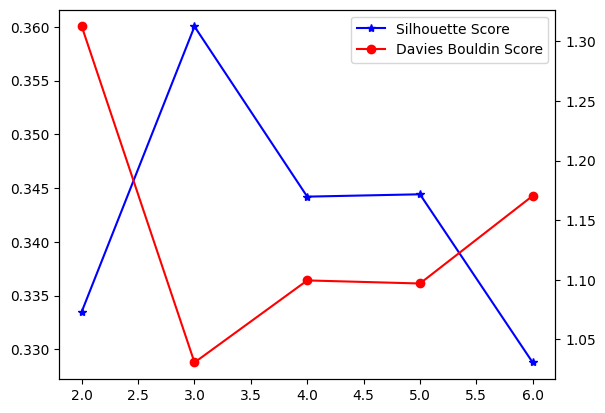

In [5]:
label_dict = {
    n_clusters:
        KMeans(
            n_clusters=n_clusters,
            init='random',
            n_init=1000,
            random_state=random_state,
        ).fit_predict(cross_correlation) + 1
    for n_clusters in N_CLUSTERS_LIST
}

# Validity measures of clusters:
# - Silhouette Score: higher is better
# - Davies-Bouldin Index: LOWER is better
SS_scores = [silhouette_score(cross_correlation, label) for label in label_dict.values()]
DBI_scores = [davies_bouldin_score(cross_correlation, label) for label in label_dict.values()]
scores_df = pd.DataFrame(dict(silhouette_scores=SS_scores, davies_bouldin_scores=DBI_scores))
scores_df.index = N_CLUSTERS_LIST
scores_df.index.name = 'n_clusters'
scores_df.to_csv( RESULT_FOLDER / 'internal_validity/GMV_inhouse.csv')
# fast plot for the scores
line1, = plt.plot(N_CLUSTERS_LIST, SS_scores, 'b-*', )
plt.twinx()
line2, = plt.plot(N_CLUSTERS_LIST, DBI_scores, 'ro-', )
plt.legend([line1, line2], ['Silhouette Score', 'Davies Bouldin Score'])

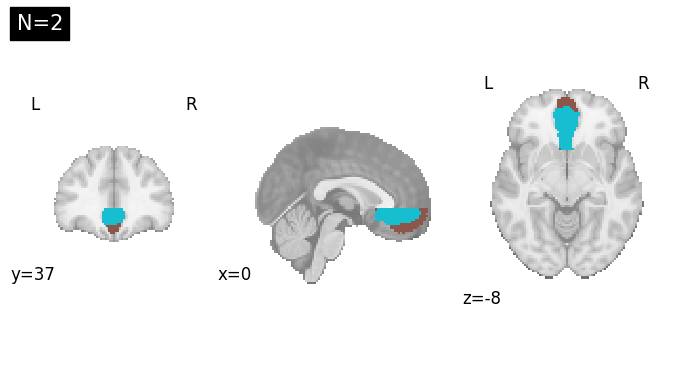

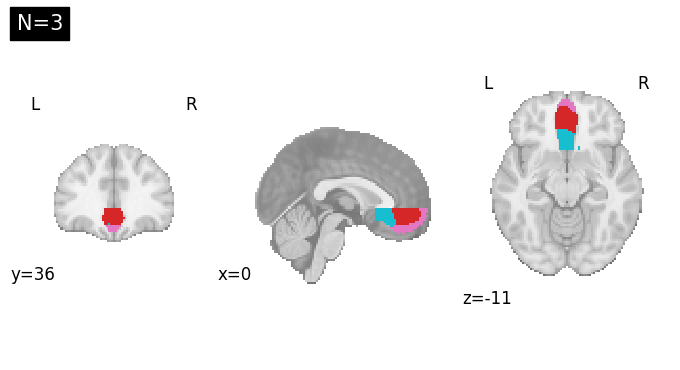

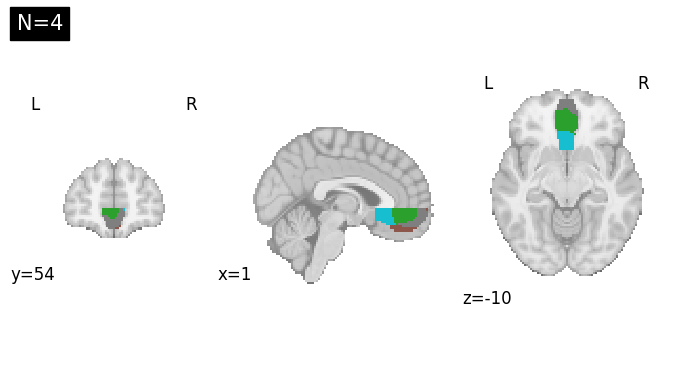

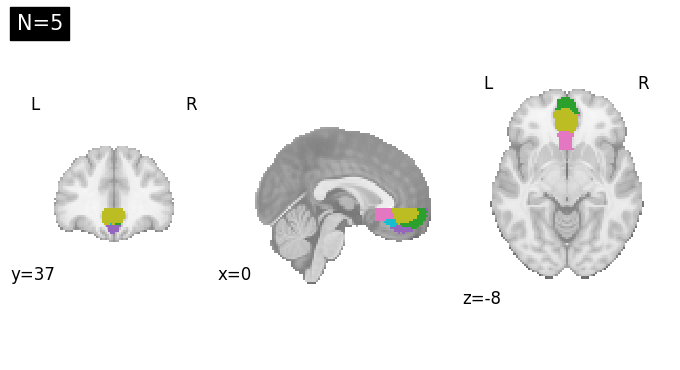

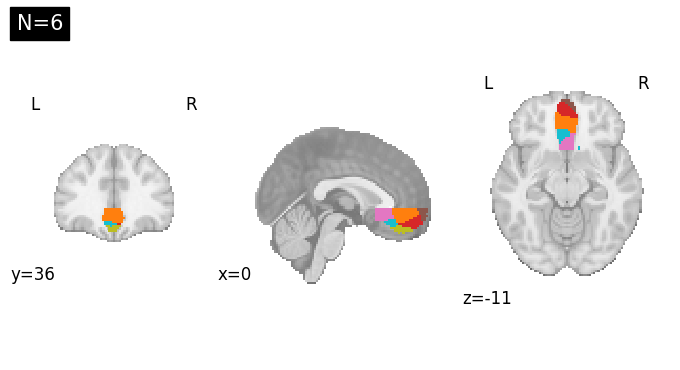

In [6]:
for n_clusters in N_CLUSTERS_LIST:
    label_img_data = np.zeros_like(ROI_MASK, dtype=np.int8)
    label_img_data[ROI_MASK] = label_dict[n_clusters]
    label_img = nib.nifti1.Nifti1Image(label_img_data, header=ROI_IMAGE.header, affine=ROI_IMAGE.affine, )
    nib.save(label_img, str(RESULT_FOLDER / f'nii/GMV_inhouse_K{n_clusters}.nii.gz'))
    # fast plot for labels
    nplt.plot_stat_map(label_img, title=f'N={n_clusters}', cmap='tab10', draw_cross=False, colorbar=False, )

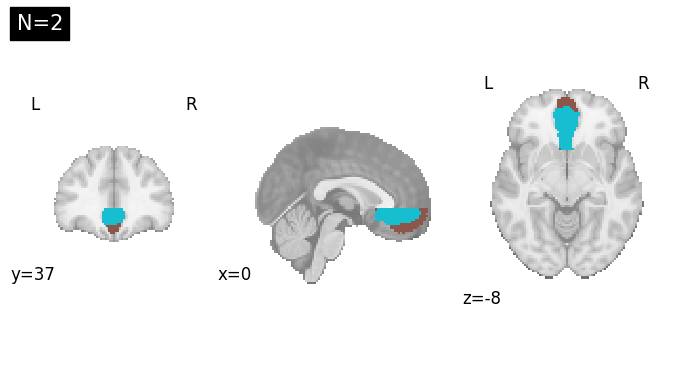

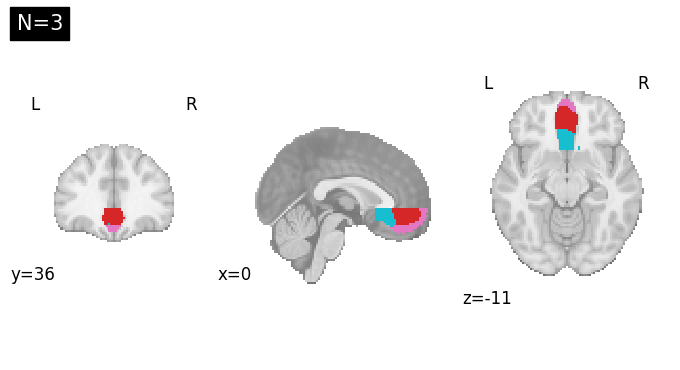

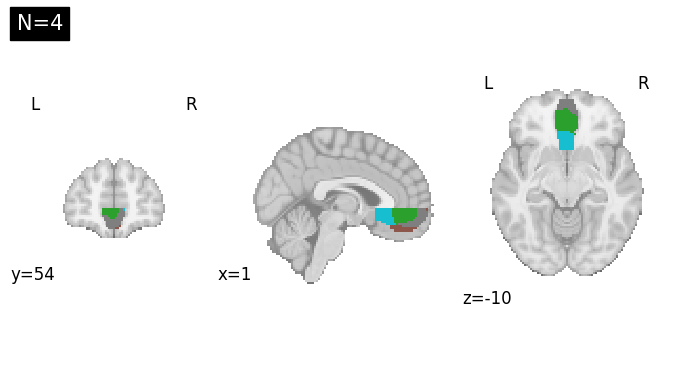

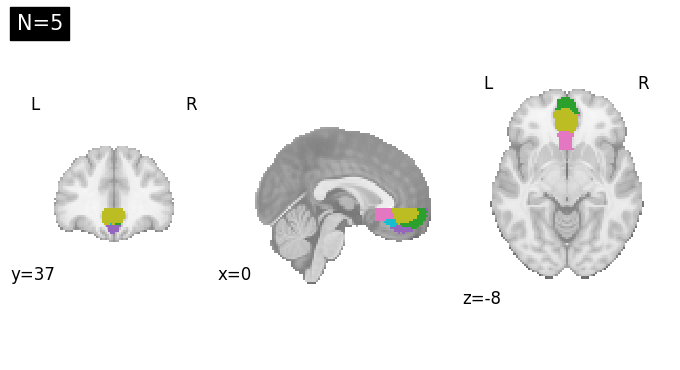

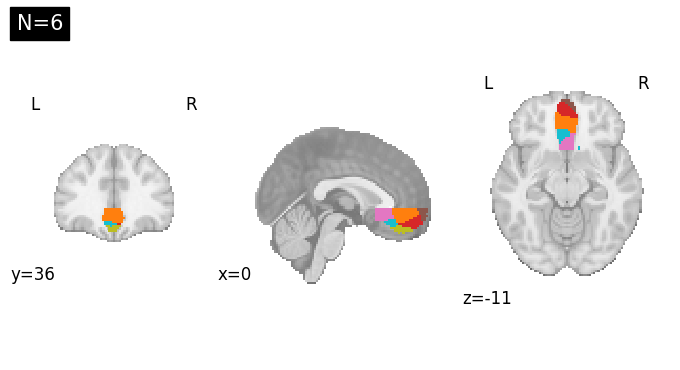

In [7]:
for n_clusters in N_CLUSTERS_LIST:
    label_img_data = np.zeros_like(ROI_MASK, dtype=np.int8)
    label_img_data[ROI_MASK] = label_dict[n_clusters]
    label_img = nib.nifti1.Nifti1Image(label_img_data, header=ROI_IMAGE.header, affine=ROI_IMAGE.affine, )
    nib.save(label_img, str(RESULT_FOLDER / f'nii/GMV_inhouse_K{n_clusters}.nii.gz'))
    # fast plot for labels
    nplt.plot_stat_map(label_img, title=f'N={n_clusters}', cmap='tab10', draw_cross=False, colorbar=False, )

In [ ]:
for n_clusters in N_CLUSTERS_LIST:
    label_img_data = np.zeros_like(ROI_MASK, dtype=np.int8)
    label_img_data[ROI_MASK] = label_dict[n_clusters]
    label_img = nib.nifti1.Nifti1Image(label_img_data, header=ROI_IMAGE.header, affine=ROI_IMAGE.affine, )
    nib.save(label_img, str(RESULT_FOLDER / f'nii/GMV_inhouse_K{n_clusters}.nii.gz'))
    # fast plot for labels
    nplt.plot_stat_map(label_img, title=f'N={n_clusters}', cmap='tab10', draw_cross=False, colorbar=False, )

In [ ]:
for n_clusters in N_CLUSTERS_LIST:
    label_img_data = np.zeros_like(ROI_MASK, dtype=np.int8)
    label_img_data[ROI_MASK] = label_dict[n_clusters]
    label_img = nib.nifti1.Nifti1Image(label_img_data, header=ROI_IMAGE.header, affine=ROI_IMAGE.affine, )
    nib.save(label_img, str(RESULT_FOLDER / f'nii/GMV_inhouse_K{n_clusters}.nii.gz'))
    # fast plot for labels
    nplt.plot_stat_map(label_img, title=f'N={n_clusters}', cmap='tab10', draw_cross=False, colorbar=False, )

In [ ]:
for n_clusters in N_CLUSTERS_LIST:
    label_img_data = np.zeros_like(ROI_MASK, dtype=np.int8)
    label_img_data[ROI_MASK] = label_dict[n_clusters]
    label_img = nib.nifti1.Nifti1Image(label_img_data, header=ROI_IMAGE.header, affine=ROI_IMAGE.affine, )
    nib.save(label_img, str(RESULT_FOLDER / f'nii/GMV_inhouse_K{n_clusters}.nii.gz'))
    # fast plot for labels
    nplt.plot_stat_map(label_img, title=f'N={n_clusters}', cmap='tab10', draw_cross=False, colorbar=False, )

In [ ]:
for n_clusters in N_CLUSTERS_LIST:
    label_img_data = np.zeros_like(ROI_MASK, dtype=np.int8)
    label_img_data[ROI_MASK] = label_dict[n_clusters]
    label_img = nib.nifti1.Nifti1Image(label_img_data, header=ROI_IMAGE.header, affine=ROI_IMAGE.affine, )
    nib.save(label_img, str(RESULT_FOLDER / f'nii/GMV_inhouse_K{n_clusters}.nii.gz'))
    # fast plot for labels
    nplt.plot_stat_map(label_img, title=f'N={n_clusters}', cmap='tab10', draw_cross=False, colorbar=False, )

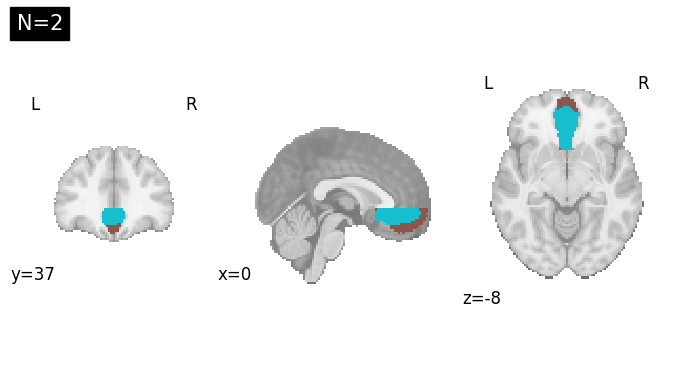

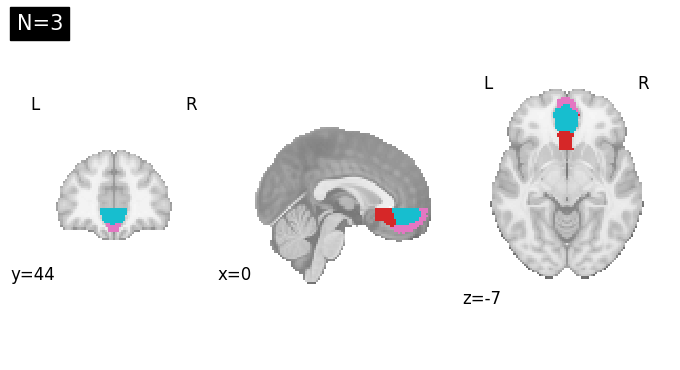

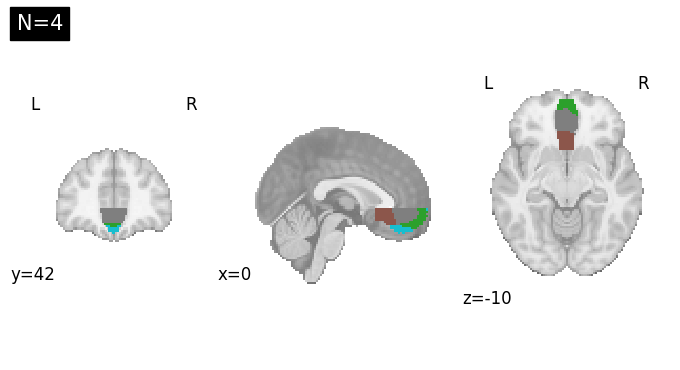

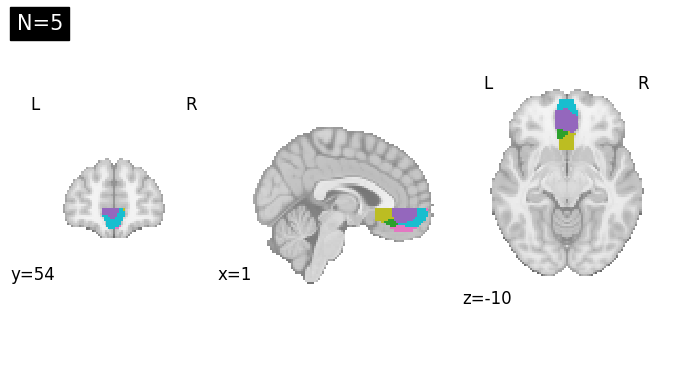

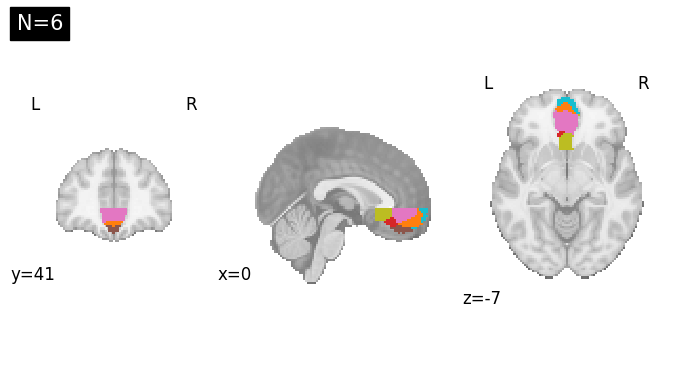

In [7]:
for n_clusters in N_CLUSTERS_LIST:
    label_img_data = np.zeros_like(ROI_MASK, dtype=np.int8)
    label_img_data[ROI_MASK] = label_dict[n_clusters]
    label_img = nib.nifti1.Nifti1Image(label_img_data, header=ROI_IMAGE.header, affine=ROI_IMAGE.affine, )
    nib.save(label_img, str(RESULT_FOLDER / f'nii/GMV_inhouse_K{n_clusters}.nii.gz'))
    # fast plot for labels
    nplt.plot_stat_map(label_img, title=f'N={n_clusters}', cmap='tab10', draw_cross=False, colorbar=False, )